[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/02_data_science/08_numpy_fundamentals.ipynb)

# 📓 Notebook 8 — NumPy Fundamentals: Vectorised Math for AI Workloads

> **Module:** Data Science Libraries · **Estimated time:** 35–50 min · **Difficulty:** Beginner / Intermediate

NumPy ("Numerical Python") is the bedrock of the entire Python data-science ecosystem. **Pandas, scikit-learn, TensorFlow, PyTorch, OpenCV** — all of them store data as NumPy arrays under the hood. Mastering NumPy is the single biggest leverage move in your early data-science journey.

The reason to care, for AI work specifically, is that **everything** — token counts, costs, latencies, probabilities, embeddings, model weights — eventually lives in a NumPy array. The same vectorised arithmetic you'll learn here is what makes `model.predict(X)` work over millions of rows in seconds.

> 🧭 **The running example.** We carry one concrete dataset through the notebook: the **latencies of our LLM API calls** — first a few raw call times, then a matrix of *3 models × 4 latency stats*, building up to an end-of-notebook A/B test of two providers. Every new tool (slicing, masking, ufuncs, broadcasting, axis-aggregation) is introduced as the next thing we need to *answer a question about those latencies*.

> 🧠 **The one mental model behind all of it.** A NumPy array is **one flat, typed block of memory** — not a Python list of boxed objects. Almost every NumPy superpower (the speed, slices-as-views, broadcasting, `dtype` surprises) is a direct consequence of that single fact. Keep the picture of *raw numbers laid end to end in one block* in your head, and NumPy stops being a bag of tricks.

## 🎯 Learning objectives

1. Create and inspect NumPy arrays (`shape`, `dtype`, `ndim`).
2. Index and slice 1-D and 2-D arrays, including with **boolean masks**.
3. Perform **vectorised arithmetic** and use **ufuncs**.
4. Understand **broadcasting** — how arrays of different shapes combine.
5. Aggregate **along an axis** (`axis=0` vs `axis=1`).
6. Reshape, stack, and split arrays.
7. Generate **reproducible** random data with `default_rng`.
8. Apply all of the above to a small AI-cost-and-latency analysis.

## ✅ Prerequisites

Notebooks 1–6.

## 1. Why NumPy?

Before any latency analysis, the *why*. For small datasets, pure Python is fine. For any serious numerical work, three problems with Python lists become unbearable — and all three trace back to the same root cause we'll keep returning to: **a list is scattered boxed objects, an array is one typed block.**

1. **Slow** — Python loops are interpreted; NumPy runs vectorised C code under the hood (often 50–500× faster).
2. **Memory-hungry** — every `int` in a Python list is a full object; a NumPy array of 1 million `int32` values uses ~4 MB instead of ~28 MB.
3. **Awkward syntax** — element-wise arithmetic on lists requires a loop or comprehension; in NumPy it's just `a + b`.

In [1]:
import numpy as np
import math
import time

# Pretend we have 5 million numeric records to process — common scale in analytics
n = 5_000_000
py_list = list(range(n))
np_arr  = np.arange(n)

# A small bit of real work per element: sqrt(x*x + x), then sum
# (e.g., a per-record score that's not just a single multiply)
t0 = time.perf_counter()
s1 = sum(math.sqrt(x*x + x) for x in py_list)
t_py = time.perf_counter() - t0

# Same formula, NumPy-vectorised
t0 = time.perf_counter()
s2 = np.sqrt(np_arr * np_arr + np_arr).sum()
t_np = time.perf_counter() - t0

assert abs(s1 - s2) / max(s1, 1) < 1e-6
print(f"Pure Python : {t_py*1000:7.1f} ms")
print(f"NumPy       : {t_np*1000:7.1f} ms   (≈ {t_py/t_np:.0f}× faster)")


Pure Python :   202.6 ms
NumPy       :    23.3 ms   (≈ 9× faster)


## 2. Creating arrays

Convinced arrays are worth it? Then we need to *make* one. Before we can analyse a single latency we need data in array form — here are the handful of constructors you'll reach for constantly:

| Call                          | Result                                    |
|-------------------------------|-------------------------------------------|
| `np.array([1, 2, 3])`         | from a Python list                        |
| `np.zeros((3, 4))`            | shape `(3, 4)`, all zeros                 |
| `np.ones((2, 5))`             | shape `(2, 5)`, all ones                  |
| `np.full((2, 2), 7)`          | filled with a constant                    |
| `np.arange(0, 10, 2)`         | 0, 2, 4, 6, 8                              |
| `np.linspace(0, 1, 5)`        | 5 evenly spaced values between 0 and 1     |
| `np.eye(3)`                   | 3×3 identity matrix                       |

In [2]:
a = np.array([1, 2, 3, 4, 5])             # from a list
b = np.zeros((3, 4))                       # all zeros
c = np.ones((2, 5))                        # all ones
d = np.full((2, 2), 7)                     # filled
e = np.arange(0, 10, 2)                    # like range, but an array
f = np.linspace(0, 1, 5)                   # 5 points between 0 and 1
g = np.eye(3)                              # identity matrix

for name, arr in [("a", a), ("b", b), ("c", c), ("d", d), ("e", e), ("f", f), ("g", g)]:
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}")
    print(arr)
    print()


a: shape=(5,), dtype=int64
[1 2 3 4 5]

b: shape=(3, 4), dtype=float64
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

c: shape=(2, 5), dtype=float64
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

d: shape=(2, 2), dtype=int64
[[7 7]
 [7 7]]

e: shape=(5,), dtype=int64
[0 2 4 6 8]

f: shape=(5,), dtype=float64
[0.   0.25 0.5  0.75 1.  ]

g: shape=(3, 3), dtype=float64
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]



> 🚫 **Misconception — "an array figures out the right dtype when I assign into it."**
> An array has **one fixed dtype**, locked in when it's created. `a = np.array([1, 2, 3])` is `int64`, so `a[0] = 9.7` stores **`9`** — the float is silently *truncated*, not rounded, and the array stays integer. If you need fractions, create it as float from the start (`np.array([1, 2, 3], dtype=float)` or `np.array([1.0, 2, 3])`).

## 3. Inspecting an array — and meet our running dataset

An array can be 1-D, 2-D, the wrong shape, or secretly the wrong `dtype` — and you can't trust any computation until you know which. So the moment you have an array, you check it. We'll inspect the dataset we carry from here on: a small **3 models × 4 latency stats** matrix (mean, p50, p95, p99, in ms). The four attributes you check first:

- `shape` — a tuple `(rows, cols, ...)`.
- `dtype` — element data type (`int64`, `float64`, `bool`, …).
- `ndim` — number of dimensions.
- `size` — total number of elements.

In [3]:
# 3 models × 4 daily latency stats (mean, p50, p95, p99) in ms
latency_stats = np.array([
    [1820, 1740, 2950, 3820],     # gpt-4o-mini
    [2410, 2280, 3640, 4480],     # claude-haiku
    [1530, 1450, 2510, 3170],     # internal-llm
])

print(f"shape : {latency_stats.shape}")    # (3, 4)
print(f"dtype : {latency_stats.dtype}")
print(f"ndim  : {latency_stats.ndim}")
print(f"size  : {latency_stats.size}")
print(f"max   : {latency_stats.max()}")
print(f"min   : {latency_stats.min()}")
print(f"mean  : {latency_stats.mean():.1f}")


shape : (3, 4)
dtype : int64
ndim  : 2
size  : 12
max   : 4480
min   : 1450
mean  : 2650.0


> 💡 **In ML and AI, `shape` is everything.** Most cryptic errors ("expected (32, 4) got (4, 32)") are shape mismatches. When you debug numerical code, *always* `print(x.shape)` first.

## 4. Indexing and slicing

We know the *shape* of our latency matrix; now we want to pull pieces out of it — *"just the p95 column,"* *"model 0's row."* For 1-D arrays this is identical to Python lists. For 2-D, the syntax is `A[row, col]` with slicing on each axis.

In [4]:
# Index by (row, col) — same matrix from the previous cell
print("Model 0 (all stats)        :", latency_stats[0])           # whole row
print("Model 0 mean latency       :", latency_stats[0, 0])         # one cell
print("P95 column across models    :", latency_stats[:, 2])        # whole column
print("Bottom-right 2×2 sub-matrix :")
print(latency_stats[-2:, -2:])


Model 0 (all stats)        : [1820 1740 2950 3820]
Model 0 mean latency       : 1820
P95 column across models    : [2950 3640 2510]
Bottom-right 2×2 sub-matrix :
[[3640 4480]
 [2510 3170]]


### ⚠️ Pitfall — a slice is a *view*, not a copy

Here is a NumPy behaviour that bites almost everyone exactly once, and it follows directly from the "one contiguous block of memory" idea from earlier: **slicing a NumPy array does not copy the data.** It hands you a *view* — a second window looking at the **same underlying memory**. So if you write into the slice, you are writing into the original array too.

```text
   original = np.array([0, 1, 2, 3, 4, 5])     (one block of memory)
                 ┌──┬──┬──┬──┬──┬──┐
                 │0 │1 │2 │3 │4 │5 │
                 └──┴──┴──┴──┴──┴──┘
                     ▲  ▲  ▲
   view = original[1:4]  selects cells 1, 2, 3   ← NOT a new block — a window onto the same memory
                 ┌──┬──┬──┐
                 │1 │2 │3 │   (these cells ARE the original's cells 1,2,3)
                 └──┴──┴──┘
   write into the view  →  the original changes too.
```

This is a *feature* — it's what makes slicing huge arrays instant and memory-free — but it surprises you the first time a function "mysteriously" mutates the array you passed in. Let's prove both the trap and the fix.

In [5]:
import numpy as np

original = np.array([0, 1, 2, 3, 4, 5])
print("original before :", original)

# A slice is a VIEW onto the same memory:
view = original[1:4]            # looks at cells 1,2,3 of `original`
view[:] = 99                    # write into the view...

print("view after      :", view)
print("original after  :", original, "  ← cells 1,2,3 changed too! 😱")

# --- The fix: .copy() detaches into fresh memory ---
original2 = np.array([0, 1, 2, 3, 4, 5])
snapshot  = original2[1:4].copy()   # independent copy, its own memory
snapshot[:] = 99                    # mutate the copy...

print("\nwith .copy():")
print("snapshot        :", snapshot)
print("original2       :", original2, "  ← untouched, as expected ✅")

original before : [0 1 2 3 4 5]
view after      : [99 99 99]
original after  : [ 0 99 99 99  4  5]   ← cells 1,2,3 changed too! 😱

with .copy():
snapshot        : [99 99 99]
original2       : [0 1 2 3 4 5]   ← untouched, as expected ✅


> 🧠 **Mental model.** Think of a slice as a **window**, not a **photograph**. A window (`arr[1:4]`) shows you part of the real array — paint on the glass and the real thing changes. A photograph (`arr[1:4].copy()`) is a detached snapshot you can scribble on safely. Default NumPy slicing gives you the window; add `.copy()` when you want the photograph.

> 💡 **Tip.** This is the opposite of plain Python lists, where `my_list[1:4]` *does* return a copy. So muscle memory from lists is exactly what trips people up in NumPy. Rule of thumb: **if you're about to modify a slice and you don't want the parent to change, call `.copy()` first.** (Boolean-mask and fancy-index results, by contrast, always return copies — only basic slices are views.)

### Boolean masking — the most powerful indexing pattern

A boolean array of the same shape can be used to index — only the `True` positions are returned. This is how you do "give me all calls where latency > 2 seconds" in pure NumPy and (with extra wrapping) in pandas.

In [6]:
# A batch of 8 individual call latencies (ms)
latencies = np.array([1820, 2150, 1640, 3180, 2410, 1740, 2530, 1380])
print(f"latencies     = {latencies}")

mask = latencies > 2000
print(f"\nlatencies > 2000  → mask = {mask}")
print(f"latencies[mask]        = {latencies[mask]}")

# Idiomatic one-liner
print(f"latencies[latencies > 2000] = {latencies[latencies > 2000]}")

# Combine masks with & (AND) and | (OR) — parentheses required!
in_band = (latencies >= 1500) & (latencies <= 2500)
print(f"\n1.5–2.5s band : {latencies[in_band]}")


latencies     = [1820 2150 1640 3180 2410 1740 2530 1380]

latencies > 2000  → mask = [False  True False  True  True False  True False]
latencies[mask]        = [2150 3180 2410 2530]
latencies[latencies > 2000] = [2150 3180 2410 2530]

1.5–2.5s band : [1820 2150 1640 2410 1740]


---

### ✋ Quick exercise (~2 min) — Flag the slow calls

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Your API gateway has an SLA of **2500 ms**. Using the `latencies` array from above, use a **boolean mask** (no loop) to find **how many** calls breached the SLA and what their **average** latency was.

In [7]:
# ✍️ Your turn 👇
# `latencies` is already defined above.
# 1) build a mask for calls slower than 2500 ms
# 2) print how many breached, and their mean latency


<details>
<summary>✅ <b>Solution</b></summary>

```python
slow = latencies[latencies > 2500]
print(f"breached SLA : {slow.size}")
print(f"their mean   : {slow.mean():.1f} ms")
```

The mask `latencies > 2500` selects only the breaching calls; `.size` counts them and `.mean()` averages just that subset (2 calls, ≈2855 ms).
</details>

## 5. Vectorised arithmetic

Slicing lets us *read* the latencies; now we want to *transform* them — convert ms to seconds, apply a formula to every call at once. In pure Python that's a loop; in NumPy it's the formula itself. This is what makes NumPy *feel* like maths: write the formula once, NumPy applies it to every element. No loops.

### 🔬 What actually happens — why `arr * 2` beats a Python loop

`arr * 2` and a `for` loop *look* like they do the same amount of work, so why is one of them often **50–200× faster**? The secret is in how the data is stored and where the loop runs. Let's open the hood.

**A Python list of numbers is a list of *pointers to objects*.** Each `int` is a full Python object sitting somewhere in memory, with a type tag, a reference count, and the value. The list just holds addresses pointing at them, scattered around:

```text
Python list  [10, 20, 30, 40]
  ┌────┬────┬────┬────┐
  │ •  │ •  │ •  │ •  │     ← four pointers
  └─┬──┴─┬──┴─┬──┴─┬──┘
    ▼    ▼    ▼    ▼
  [int][int][int][int]      ← four separate boxed objects, scattered in RAM
```

**A NumPy array is one flat, typed block of memory.** No boxes, no pointers — just the raw numbers laid end to end, all the same `dtype`:

```text
NumPy array  np.array([10, 20, 30, 40], dtype=int64)
  ┌────┬────┬────┬────┐
  │ 10 │ 20 │ 30 │ 40 │     ← raw int64 values, contiguous, no objects
  └────┴────┴────┴────┘
```

That single difference changes *everything* about how a loop over the data runs:

| | Python `for` loop over a list | NumPy `arr * 2` |
|---|---|---|
| Where the loop runs | In the **Python interpreter** (slow) | In **compiled C** (fast) |
| Per element, Python must… | unbox the object, type-check, re-box the result | nothing — values are already raw |
| Memory layout | scattered pointers → cache misses | contiguous block → cache-friendly |
| Type checking | every single element, every iteration | **once**, up front (the `dtype`) |

So the speedup isn't magic — it's the absence of per-element Python overhead. NumPy checks the type *once* (the array's `dtype`), then a tight C loop walks a contiguous buffer multiplying raw numbers, never touching a Python object. Let's measure it.

In [8]:
import numpy as np
from time import perf_counter

N = 1_000_000
data = list(range(N))           # a Python list of 1,000,000 ints
arr  = np.arange(N)             # the same numbers as a NumPy array

# --- 1) Pure-Python loop: the interpreter runs the loop, one object at a time ---
t0 = perf_counter()
out_loop = [x * 2 for x in data]
t_loop = perf_counter() - t0

# --- 2) NumPy vectorised: the C loop runs over a contiguous int64 buffer ---
t0 = perf_counter()
out_vec = arr * 2
t_vec = perf_counter() - t0

print(f"Python loop : {t_loop*1000:8.1f} ms")
print(f"NumPy arr*2 : {t_vec*1000:8.1f} ms")
print(f"Speed-up    : {t_loop/t_vec:6.0f}x faster")

# Same answer either way — vectorisation changes the SPEED, not the RESULT:
print("same result?", out_loop[:5], "==", out_vec[:5].tolist())

Python loop :     11.9 ms
NumPy arr*2 :      1.3 ms
Speed-up    :      9x faster
same result? [0, 2, 4, 6, 8] == [0, 2, 4, 6, 8]


**The speed-up, across sizes.** One timing is an anecdote; the scaling is the lesson. We repeat the loop-vs-vectorised race over a range of array sizes and plot both. The Python loop's time grows in lock-step with the data; NumPy's C loop over a contiguous buffer stays far below it — a roughly constant, large multiple that *is* the reason every numeric library is built on arrays.


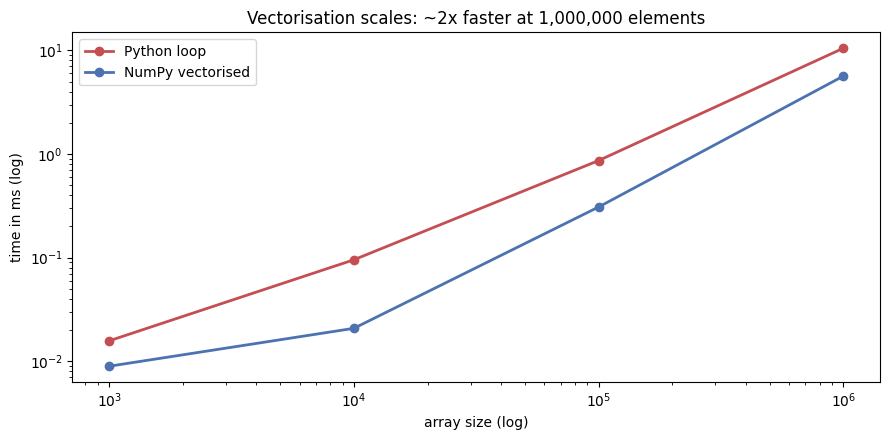

In [9]:
sizes = [1_000, 10_000, 100_000, 1_000_000]
loop_ms, vec_ms = [], []
for N in sizes:
    data, arr = list(range(N)), np.arange(N)
    t0 = perf_counter(); _ = [x * 2 for x in data]; loop_ms.append((perf_counter() - t0) * 1000)
    t0 = perf_counter(); _ = arr * 2;               vec_ms.append((perf_counter() - t0) * 1000)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sizes, loop_ms, "o-", color="#C44E52", lw=2, label="Python loop")
ax.plot(sizes, vec_ms,  "o-", color="#4C72B0", lw=2, label="NumPy vectorised")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set(xlabel="array size (log)", ylabel="time in ms (log)",
       title=f"Vectorisation scales: ~{loop_ms[-1]/vec_ms[-1]:.0f}x faster at {sizes[-1]:,} elements")
ax.legend(); plt.tight_layout(); plt.show()


The number you just printed is large — and the reason is exactly the table above. Trace one element through both paths:

```text
  Python loop, per element              NumPy, per element
  ────────────────────────              ───────────────────
  1. fetch pointer from list            (loop is in C, not Python)
  2. unbox → real C int                 1. read raw int64 from buffer
  3. multiply by 2                      2. multiply by 2
  4. box result → new int object        3. write raw int64 to output
  5. store pointer in new list
        ▲ steps 1,2,4,5 are PURE OVERHEAD       ▲ no boxing, no pointers
          — repeated 1,000,000 times              — just arithmetic
```

The arithmetic (step 3) is identical. Everything *around* it — the boxing, unboxing, pointer-chasing, and per-element type checks — is what the Python loop pays a million times and NumPy pays **zero** times.

> 🧠 **Mental model.** A Python loop is the interpreter picking up one wrapped present at a time, unwrapping it, doing the math, then re-wrapping the answer. NumPy hands the whole pallet of *unwrapped* numbers to a C routine that rips through them in one pass. "Vectorised" literally means *"the loop happens down in C, not up here in Python."*

> 🎯 **Intuition.** Whenever you catch yourself writing `for i in range(len(arr)): ...` to do math on a NumPy array, stop — there is almost always a vectorised expression (`arr * 2`, `a + b`, `np.sqrt(arr)`) that is both shorter *and* dramatically faster. Reaching for the loop is the single most common performance mistake beginners make with NumPy.

> ⚠️ **Pitfall.** The speedup depends on the array having a **numeric `dtype`** (`int64`, `float64`, …). An array of Python objects — `np.array([...], dtype=object)` — falls back to boxed objects and loses the advantage entirely. If your "fast" NumPy code is mysteriously slow, check `arr.dtype`; if it says `object`, that's your culprit.

In [10]:
# Convert latencies from ms to seconds — one expression, no loop
latencies_ms = np.array([1820, 2150, 1640, 3180, 2410, 1740, 2530, 1380])
latencies_s  = latencies_ms / 1000
print(f"ms : {latencies_ms}")
print(f"s  : {latencies_s}")

# Element-wise arithmetic between arrays of the same shape
tokens_in  = np.array([480, 720, 305, 610, 815, 290, 720, 410])
tokens_out = np.array([120, 200,  80, 175, 240,  95, 215, 130])

# Cost of every call in one vectorised expression — no Python loop required
price_in_per_1k  = 0.0006
price_out_per_1k = 0.0024

cost = tokens_in / 1000 * price_in_per_1k + tokens_out / 1000 * price_out_per_1k
print(f"\ncost (USD) per call:")
print(cost.round(5))
print(f"total cost: ${cost.sum():.5f}")


ms : [1820 2150 1640 3180 2410 1740 2530 1380]
s  : [1.82 2.15 1.64 3.18 2.41 1.74 2.53 1.38]

cost (USD) per call:
[0.00058 0.00091 0.00037 0.00079 0.00106 0.0004  0.00095 0.00056]
total cost: $0.00562


### Universal functions (ufuncs)

NumPy provides element-wise versions of every common math function. They are *fast* and they handle entire arrays at once. You'll see `np.exp`, `np.log`, `np.sqrt`, `np.abs`, `np.sin`, `np.cos`, … everywhere in ML code (especially in loss functions, softmax, attention).

In [11]:
x = np.linspace(0, 2 * np.pi, 5)
print(f"x       : {x.round(3)}")
print(f"sin(x)  : {np.sin(x).round(3)}")
print(f"cos(x)  : {np.cos(x).round(3)}")
print(f"exp(x)  : {np.exp(x).round(3)}")
print(f"log1p(x): {np.log1p(x).round(3)}")
print(f"sqrt(x) : {np.sqrt(x).round(3)}")


x       : [0.    1.571 3.142 4.712 6.283]
sin(x)  : [ 0.  1.  0. -1. -0.]
cos(x)  : [ 1.  0. -1. -0.  1.]
exp(x)  : [  1.      4.81   23.141 111.318 535.492]
log1p(x): [0.    0.944 1.421 1.743 1.986]
sqrt(x) : [0.    1.253 1.772 2.171 2.507]


## 6. Broadcasting — the rule that powers most of NumPy

Vectorised arithmetic was easy when both sides had the *same* shape. But the real questions aren't like that — *"subtract each model's mean latency from its row,"* *"add a per-column adjustment to a whole matrix."* There the shapes differ. What if two arrays have *different* shapes? NumPy tries to *stretch* the smaller one to match. The rule is:

> Compare shapes from the **right**. Dimensions are compatible when they are **equal** or one of them is **1**.

Two examples make this concrete.

In [12]:
# Example 1: array + scalar — scalar broadcasts to every element
a = np.array([1, 2, 3, 4])
print(f"a + 100 = {a + 100}")

# Example 2: row vector + matrix
# Use case: we have a matrix of token counts for many calls × 2 columns (in, out)
# and we want to multiply each column by its own per-1K price.
calls = np.array([
    [480, 120],
    [720, 200],
    [305,  80],
    [610, 175],
])
prices_per_1k = np.array([0.0006, 0.0024])   # shape (2,)

# Cost = element-wise multiply then sum across the (in, out) axis
per_call_cost = (calls / 1000 * prices_per_1k).sum(axis=1)
print(f"\ncosts: {per_call_cost.round(5)}")
print(f"total: ${per_call_cost.sum():.5f}")


a + 100 = [101 102 103 104]

costs: [0.00058 0.00091 0.00037 0.00079]
total: $0.00265


> 🎯 **Mental model.** "Compatible shapes" means: line them up from the right; each pair of dimensions must be equal, or one must be 1. Then the array with the 1 gets stretched to match. This one rule replaces what would otherwise be hundreds of nested loops.

### 🔬 What actually happens — the broadcasting algorithm, step by step

The one-line rule above ("compare from the right; equal or one-is-1") is doing a lot of work. Here is the **exact algorithm** NumPy runs to decide whether two shapes are compatible and what the result shape will be.

Take a concrete case: a **column** of shape `(3, 1)` plus a **row** of shape `(1, 4)`.

**Step 1 — align the shapes from the RIGHT.** Write both shapes right-justified, one above the other:

```text
        axis:   0    1
        (3, 1)  3    1
        (1, 4)  1    4
                ▲    ▲
            compare each column independently
```

**Step 2 — check each dimension pair.** They are compatible if **equal**, OR **one of them is 1**:

```text
   axis 1:  1 vs 4  →  one is 1  ✓  → result is 4
   axis 0:  3 vs 1  →  one is 1  ✓  → result is 3
                                       ─────────────
                              result shape = (3, 4)
```

**Step 3 — "stretch" each size-1 dimension** (virtually — no data is copied):

```text
  (3,1)  column        stretched to (3,4)          (1,4) row     stretched to (3,4)
  ┌───┐                ┌───┬───┬───┬───┐            ┌──┬──┬──┬──┐  ┌──┬──┬──┬──┐
  │ a │                │ a │ a │ a │ a │            │p │q │r │s │  │p │q │r │s │
  ├───┤      ───►      ├───┼───┼───┼───┤            └──┴──┴──┴──┘  ├──┼──┼──┼──┤
  │ b │                │ b │ b │ b │ b │                           │p │q │r │s │
  ├───┤                ├───┼───┼───┼───┤                           ├──┼──┼──┼──┤
  │ c │                │ c │ c │ c │ c │                           │p │q │r │s │
  └───┘                └───┴───┴───┴───┘                           └──┴──┴──┴──┘
   the single column is reused                    the single row is reused
   across all 4 output columns                    across all 3 output rows
```

**Step 4 — combine element-wise** on the two `(3, 4)` virtual grids. The `(i, j)` output is `column[i] + row[j]` — every pairwise combination, in one expression. Let's watch it happen.

In [13]:
import numpy as np

col = np.array([[10], [20], [30]])      # shape (3, 1) — a column
row = np.array([[1, 2, 3, 4]])          # shape (1, 4) — a row

print("col.shape =", col.shape)
print("row.shape =", row.shape)

result = col + row                      # broadcasting → shape (3, 4)
print("\ncol + row  → shape", result.shape, "\n")
print(result)

# Read it back: result[i, j] == col[i] + row[j].
# Row 0 is 10 + [1,2,3,4]; row 1 is 20 + [1,2,3,4]; row 2 is 30 + [1,2,3,4].
print("\ncheck result[2, 3] == 30 + 4 ==", result[2, 3])

col.shape = (3, 1)
row.shape = (1, 4)

col + row  → shape (3, 4) 

[[11 12 13 14]
 [21 22 23 24]
 [31 32 33 34]]

check result[2, 3] == 30 + 4 == 34


Notice what broadcasting **saved** you: without it, building that `(3, 4)` table would need a double loop —

```python
for i in range(3):
    for j in range(4):
        result[i, j] = col[i, 0] + row[0, j]
```

— nine lines and slow Python. Broadcasting expresses the same thing as `col + row`, and runs it in C. And crucially, the "stretching" in Step 3 is **virtual**: NumPy does *not* actually build a `(3, 4)` copy of `col` in memory. It just reuses the single column three logical times as the C loop runs. That's why broadcasting is fast *and* memory-cheap.

**But what if the shapes genuinely can't align?** Then there is no valid stretch, and NumPy refuses — it raises a `ValueError` rather than guessing. The classic case is two 1-D arrays of different lengths, like `(3,)` and `(4,)`: line them up from the right and you get `3 vs 4` — neither equal nor 1 — so there's no way to make them match.

In [14]:
import numpy as np

a = np.array([1, 2, 3])        # shape (3,)
b = np.array([10, 20, 30, 40]) # shape (4,)

# Align from the right:  3 vs 4  →  not equal, and neither is 1  →  INCOMPATIBLE.
# We wrap it in try/except so the cell still runs cleanly and we can read the error.
try:
    c = a + b
    print("result:", c)            # we never get here
except ValueError as err:
    print("❌ ValueError — broadcasting refused:")
    print("  ", err)
    print("\nWhy: shapes (3,) and (4,) line up as  3 vs 4 — not equal, neither is 1.")
    print("Fix: make one side length-1 (e.g. b[:3]) or reshape so a size-1 dim can stretch.")

❌ ValueError — broadcasting refused:
   operands could not be broadcast together with shapes (3,) (4,) 

Why: shapes (3,) and (4,) line up as  3 vs 4 — not equal, neither is 1.
Fix: make one side length-1 (e.g. b[:3]) or reshape so a size-1 dim can stretch.


> 🧠 **Mental model — broadcasting in three words: *align, stretch, combine*.** Right-justify the shapes; any dimension that's `1` gets stretched to match its partner (for free, no copy); then NumPy combines element-wise. If a pair is *neither equal nor 1*, there's no legal stretch and you get a `ValueError`.

> 🎯 **Intuition.** A size-`1` dimension is a wildcard meaning *"reuse me for every position on this axis."* That's why `(3, 1) + (1, 4)` builds a full `(3, 4)` grid of pairwise sums, and why `X - X.mean(axis=0)` (a `(10, 3)` matrix minus a `(3,)` row of column means) subtracts the right mean from each column — the length-3 row is stretched down all 10 rows.

> ⚠️ **Pitfall — the silent off-by-orientation bug.** Broadcasting is *too* helpful sometimes. A `(3,)` row and a `(3, 1)` column will happily broadcast to a `(3, 3)` grid instead of erroring — so if you accidentally feed a column where you meant a row, you may get a plausible-looking square matrix instead of the elementwise result you intended. When a result has a surprising shape, print `.shape` on both inputs *before* the operation.

### 🔮 Predict the output

A **column** of shape `(3, 1)` plus a **row** of shape `(1, 4)`. Neither is a scalar, and the shapes don't match. What is the shape of the result — does it error, or broadcast?

```python
import numpy as np

col = np.arange(3).reshape(3, 1)   # shape (3, 1)
row = np.arange(4).reshape(1, 4)   # shape (1, 4)
print((col + row).shape)
```

Predict the shape **before** running.

In [15]:
import numpy as np

col = np.arange(3).reshape(3, 1)   # shape (3, 1)
row = np.arange(4).reshape(1, 4)   # shape (1, 4)
print("result shape:", (col + row).shape)

result shape: (3, 4)


<details>
<summary>💡 <b>Answer</b></summary>

**`(3, 4)`.** Compare the shapes from the right: `(3, 1)` vs `(1, 4)`. In each position one side is `1`, so it gets *stretched* to the other side's size — the column repeats across 4 columns, the row repeats down 3 rows. The result takes the **maximum** in each dimension: `(3, 4)`. This "outer" pattern is how a `(3, 1)` column and a `(1, 4)` row combine into a full grid with **no loops** — exactly the trick behind the pairwise-distance stretch exercise.
</details>

---

### ✋ Quick exercise (~2 min) — Cost per model via broadcasting

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You have weekly call volumes for **3 models × 4 weeks** and a **per-call price** for each model. Use **broadcasting** (no loop) to build the cost matrix, then `sum(axis=1)` for each model's 4-week total.

```python
calls = np.array([[120, 135,  98, 110],
                  [ 88,  92, 101,  79],
                  [150, 142, 138, 160]])
price_per_call = np.array([0.0006, 0.0011, 0.0004]).reshape(3, 1)  # shape (3, 1)
```

In [16]:
# ✍️ Your turn 👇
calls = np.array([[120, 135,  98, 110],
                  [ 88,  92, 101,  79],
                  [150, 142, 138, 160]])
price_per_call = np.array([0.0006, 0.0011, 0.0004]).reshape(3, 1)

# multiply (broadcasting) then total per model with sum(axis=1)


<details>
<summary>✅ <b>Solution</b></summary>

```python
weekly_cost = calls * price_per_call        # (3,4) * (3,1) -> (3,4)
print(weekly_cost.round(4))
print(weekly_cost.sum(axis=1).round(4))     # total cost per model
```

The `(3, 1)` price column stretches across all 4 week-columns, so each model's row is scaled by its own price; `sum(axis=1)` then collapses the weeks into one total per model.
</details>

## 7. Aggregations along an axis

Back to our 3×4 latency matrix. A whole-array `.mean()` gives one number — useless here, because we want *"the average per model"* (down each row) or *"the average per stat"* (down each column). That choice is what an **axis** picks. Sum, mean, max, min — these all work over the whole array by default, but you can ask for them along a specific **axis**.

- `axis=0` → collapse rows → one value per column.
- `axis=1` → collapse columns → one value per row.

```
                     mean    p50     p95     p99
   gpt-4o-mini       1820    1740    2950    3820
   claude-haiku      2410    2280    3640    4480   ← mean(axis=1) → one value per row (model)
   internal-llm      1530    1450    2510    3170

   mean(axis=0)       ↓       ↓       ↓       ↓    (one value per column = per stat)
```

In [17]:
# Same matrix as section 3: 3 models × 4 latency stats
latency_stats = np.array([
    [1820, 1740, 2950, 3820],     # gpt-4o-mini
    [2410, 2280, 3640, 4480],     # claude-haiku
    [1530, 1450, 2510, 3170],     # internal-llm
])

print(f"sum()            : {latency_stats.sum()}              (everything)")
print(f"mean(axis=0)     : {latency_stats.mean(axis=0)}   (mean of each stat across models)")
print(f"mean(axis=1)     : {latency_stats.mean(axis=1)}   (mean of each model across stats)")
print()
print(f"argmin(axis=0)   : {latency_stats.argmin(axis=0)}        (fastest model for each stat)")
print(f"argmax(axis=1)   : {latency_stats.argmax(axis=1)}        (worst stat for each model)")


sum()            : 31800              (everything)
mean(axis=0)     : [1920.         1823.33333333 3033.33333333 3823.33333333]   (mean of each stat across models)
mean(axis=1)     : [2582.5 3202.5 2165. ]   (mean of each model across stats)

argmin(axis=0)   : [2 2 2 2]        (fastest model for each stat)
argmax(axis=1)   : [3 3 3]        (worst stat for each model)


**See the latency profile.** The same `latency_stats` matrix is much easier to read as a picture - each model's four stats side by side. Notice `internal-llm` is the shortest bar in *every* group: exactly what `argmin(axis=0)` reported above. 📊

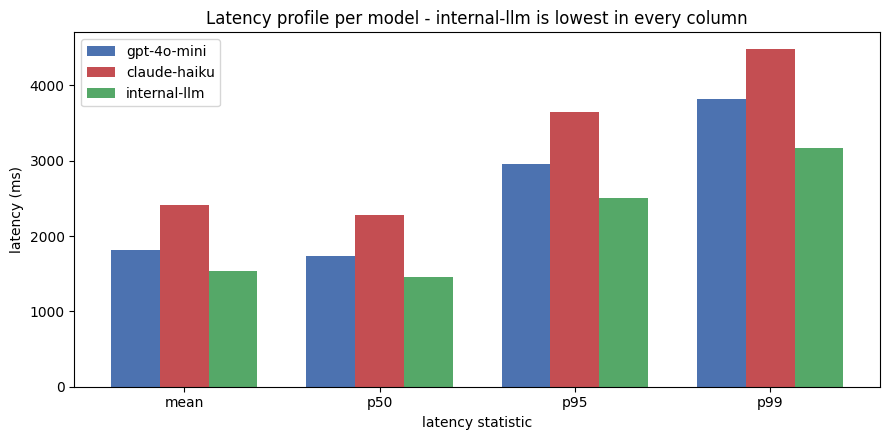

In [18]:
import matplotlib.pyplot as plt

models = ["gpt-4o-mini", "claude-haiku", "internal-llm"]
stats  = ["mean", "p50", "p95", "p99"]
colors = ["#4C72B0", "#C44E52", "#55A868"]

x = np.arange(len(stats))          # one group per latency statistic
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, model in enumerate(models):
    ax.bar(x + (i - 1) * width, latency_stats[i], width, label=model, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(stats)
ax.set(xlabel="latency statistic", ylabel="latency (ms)",
       title="Latency profile per model - internal-llm is lowest in every column")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Reshape, stack, split

We've been *reading* shapes (`.shape`) and *exploiting* them (broadcasting, axes). The last move is *changing* them — and to build our A/B test we'll need exactly this: stacking two providers' latencies into one matrix. Manipulating shapes is one of the most common operations in ML — you'll reshape feature matrices, stack batches, split features and labels.

In [19]:
x = np.arange(12)
print(f"x : shape={x.shape} → {x}")

# reshape — must keep total size the same
m34 = x.reshape(3, 4)
m43 = x.reshape(4, 3)
print(f"\nreshape (3,4):\n{m34}")

# Use -1 to let NumPy figure out one dimension automatically
auto = x.reshape(-1, 4)
print(f"\nreshape (-1, 4): shape={auto.shape}\n{auto}")

# Flatten back to 1-D
print(f"\nflatten : {m34.flatten()}")


x : shape=(12,) → [ 0  1  2  3  4  5  6  7  8  9 10 11]

reshape (3,4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

reshape (-1, 4): shape=(3, 4)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

flatten : [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [20]:
# Stacking arrays
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("hstack (1-D concat) :", np.hstack([a, b]))
print("vstack (stack rows) :\n", np.vstack([a, b]))
print("column_stack (cols) :\n", np.column_stack([a, b]))


hstack (1-D concat) : [1 2 3 4 5 6]
vstack (stack rows) :
 [[1 2 3]
 [4 5 6]]
column_stack (cols) :
 [[1 4]
 [2 5]
 [3 6]]


## 9. Random data — reproducibly

Our A/B test needs *two batches of latencies to compare* — but we don't have a live API here, so we'll **simulate** them. The catch: for experiments and demos you want random data that *isn't actually random*: you want the same numbers every time you run the notebook so results are reproducible. Use `np.random.default_rng(seed)`.

In [21]:
rng = np.random.default_rng(seed=42)

print("rng.random((3, 4)):")
print(rng.random((3, 4)).round(3))

print("\nrng.integers(low=0, high=10, size=(2, 5)):")
print(rng.integers(0, 10, size=(2, 5)))

print("\nrng.normal(mean=50, std=15, size=8):")
print(rng.normal(50, 15, size=8).round(2))

print("\nrng.choice(['gpt-4o-mini','claude-haiku'], size=5):")
print(rng.choice(["gpt-4o-mini", "claude-haiku"], size=5))


rng.random((3, 4)):
[[0.774 0.439 0.859 0.697]
 [0.094 0.976 0.761 0.786]
 [0.128 0.45  0.371 0.927]]

rng.integers(low=0, high=10, size=(2, 5)):
[[7 6 4 8 5]
 [4 4 2 0 5]]

rng.normal(mean=50, std=15, size=8):
[35.62 63.18 49.25 47.23 39.79 68.34 47.68 43.58]

rng.choice(['gpt-4o-mini','claude-haiku'], size=5):
['claude-haiku' 'gpt-4o-mini' 'gpt-4o-mini' 'gpt-4o-mini' 'gpt-4o-mini']


> 💡 The old `np.random.seed` / `np.random.rand` API still works, but the **Generator API** (`default_rng`) is the modern way: explicit, isolated, and it supports parallel streams when you need them.

---

### ✋ Quick exercise (~2 min) — Simulate a reproducible latency sample

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Using the modern Generator API, create an `rng` seeded with **7**, draw **12** latency samples from a normal distribution (mean **2000** ms, std **300** ms), `reshape` them into a **3 models × 4 measurements** matrix, and print each model's **mean** latency.

In [22]:
# ✍️ Your turn 👇
# 1) rng = np.random.default_rng(seed=7)
# 2) draw 12 normal samples, reshape to (3, 4)
# 3) print the per-model mean with mean(axis=1)


<details>
<summary>✅ <b>Solution</b></summary>

```python
rng = np.random.default_rng(seed=7)
samples = rng.normal(2000, 300, size=12).reshape(3, 4)
print(samples.round(1))
print(samples.mean(axis=1).round(1))   # per-model mean
```

Seeding `default_rng` makes the draw reproducible; `reshape(3, 4)` lays the 12 samples into 3 model-rows, and `mean(axis=1)` averages across each row's 4 measurements.
</details>

## 10. Putting it all together — the latency A/B test

Here's where every piece of the running example pays off. We've inspected latency arrays, sliced them, done vectorised math, broadcast, aggregated by axis, and learned reproducible randomness — now we use *all of it at once* on the question the whole notebook was building toward. Suppose your team is comparing **two LLM providers** on the same 50 prompts. We will simulate the latencies, then ask: which provider is faster *on average*, by how much, and is the difference statistically meaningful?

This combines indexing, vectorised arithmetic, axis aggregation, and `argsort`.

In [23]:
rng = np.random.default_rng(seed=0)

n = 50
# Simulate: provider A has mean 2.0s with std 0.5s; provider B has 2.4s with std 0.7s
latency_a = rng.normal(loc=2.0, scale=0.5, size=n).clip(min=0.2)
latency_b = rng.normal(loc=2.4, scale=0.7, size=n).clip(min=0.2)

In [24]:
# Stack into a (50, 2) matrix so we can use axis ops
both = np.column_stack([latency_a, latency_b])
labels = np.array(["A", "B"])

print(f"shape         : {both.shape}")
print(f"mean (axis=0) : {both.mean(axis=0).round(3)}  (one per provider)")
print(f"median        : {np.median(both, axis=0).round(3)}")
print(f"std           : {both.std(axis=0).round(3)}")
print(f"max           : {both.max(axis=0).round(3)}")

shape         : (50, 2)
mean (axis=0) : [2.064 2.423]  (one per provider)
median        : [2.05  2.435]
std           : [0.456 0.706]
max           : [2.98  3.802]


In [25]:
# Which prompts (rows) did A beat B on?
a_won = latency_a < latency_b
print(f"\nA was faster on {a_won.sum()} / {n} prompts ({a_won.mean():.0%})")

# A simple "effect size": mean difference / pooled std
diff = latency_b - latency_a
print(f"Mean difference (B - A): {diff.mean():.3f} s")
print(f"Effect size            : {diff.mean() / diff.std():.2f}  (≈ Cohen's d, rough rule: >0.5 is meaningful)")


A was faster on 34 / 50 prompts (68%)
Mean difference (B - A): 0.359 s
Effect size            : 0.41  (≈ Cohen's d, rough rule: >0.5 is meaningful)


**The result you can see.** The effect size is a single number; the picture is the intuition. Provider B's whole distribution sits to the *right* of A's - slower, prompt after prompt - and the dashed lines mark each provider's mean. 📊

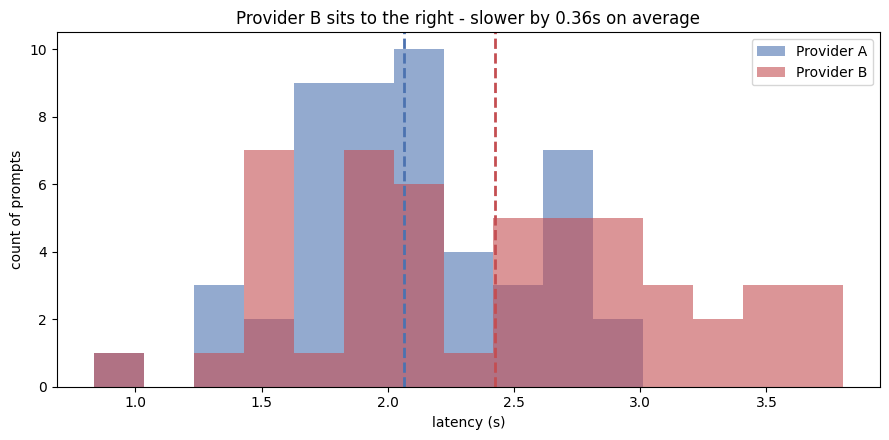

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(both.min(), both.max(), 16)
ax.hist(latency_a, bins=bins, alpha=0.6, color="#4C72B0", label="Provider A")
ax.hist(latency_b, bins=bins, alpha=0.6, color="#C44E52", label="Provider B")
ax.axvline(latency_a.mean(), color="#4C72B0", ls="--", lw=2)
ax.axvline(latency_b.mean(), color="#C44E52", ls="--", lw=2)
ax.set(xlabel="latency (s)", ylabel="count of prompts",
       title=f"Provider B sits to the right - slower by {diff.mean():.2f}s on average")
ax.legend()
plt.tight_layout()
plt.show()

> 💡 **`.std()` and `ddof`.** NumPy's `.std()` defaults to the *population* standard deviation (`ddof=0`). When your data is a *sample* you use to estimate a larger population, pass `ddof=1`. NB 10 (statistics) explains when each is right — and a Stretch exercise below switches to `ddof=1`, so the difference won't surprise you.

**What just happened?**

- We simulated two parallel batches of 50 latencies using **`default_rng`**.
- We stacked them with **`np.column_stack`** so each *row* is a paired observation.
- **`axis=0`** gave us per-provider stats (mean, median, std).
- A **boolean mask** (`latency_a < latency_b`) counted how often A beat B.
- We computed a simple **effect size** without any extra library.

That's the entire shape of an A/B-test analysis in seven lines of code.

## 🧪 Practice exercises

### Exercise 1 — ⭐ Create and slice

1. Create a 4×4 array containing the numbers 1–16.
2. Print the second row.
3. Print the third column.
4. Print the **bottom-right 2×2** sub-matrix.

In [27]:
# Your code here  👇
import numpy as np


<details>
<summary>💡 <b>Solution</b></summary>

```python
A = np.arange(1, 17).reshape(4, 4)
print(A)
print()
print("row 1 :", A[1])
print("col 2 :", A[:, 2])
print("bottom-right 2×2:\n", A[-2:, -2:])
```
</details>

### Exercise 2 — ⭐⭐ Vectorised z-score

Given a 1-D array `x` of customer satisfaction scores, compute its **z-score**: subtract the mean, divide by the standard deviation. Verify that the result has mean ≈ 0 and std ≈ 1.

In [28]:
# Your code here  👇
x = np.array([3.5, 4.1, 4.3, 2.9, 3.8, 4.7, 3.2, 4.0, 4.5, 3.6])


<details>
<summary>💡 <b>Solution</b></summary>

```python
z = (x - x.mean()) / x.std()
print("z         :", z.round(3))
print("z.mean()  :", round(float(z.mean()), 6))
print("z.std()   :", round(float(z.std()),  6))
```

Standardising features so they have mean 0 and std 1 is one of the most common preprocessing steps in ML — you'll see scikit-learn's `StandardScaler` do exactly this in NB 14.
</details>

### Exercise 3 — ⭐⭐ Boolean filtering on latencies

Given an array of call latencies in milliseconds, print:

1. The number of *slow* calls (latency > 3000 ms).
2. The mean latency of *fast* calls (< 1500 ms).
3. A new array where any latency above 5000 is clipped to 5000.

In [29]:
# Your code here  👇
latencies = np.array([1850, 2510, 3520, 1240, 2810, 4220, 980, 1990, 3110, 870, 2240, 4870])


<details>
<summary>💡 <b>Solution</b></summary>

```python
n_slow = (latencies > 3000).sum()
print(f"Slow calls         : {n_slow}")

fast_mean = latencies[latencies < 1500].mean()
print(f"Mean of fast calls : {fast_mean:.1f} ms")

clipped = np.clip(latencies, None, 5000)
print(f"Clipped            : {clipped}")
```

**Pattern.** `(condition).sum()` counts how many entries satisfy a condition — `True` and `False` are summed as `1` and `0`. You'll use this trick constantly when evaluating models ("how many predictions were correct?").
</details>

### Exercise 4 — ⭐⭐ Broadcasting in action

You have a 10×3 feature matrix `X` where columns are (`age`, `monthly_spend`, `nps_score`). Standardise **each column** to have mean 0 and std 1 — i.e. subtract the column mean and divide by the column std. Do it in **one expression** using broadcasting (no loops).

In [30]:
# Your code here  👇
rng = np.random.default_rng(0)
X = rng.normal(loc=[35, 80, 7], scale=[10, 25, 1.5], size=(10, 3))
print("Original X (rounded):\n", X.round(2))
print("\nCol means :", X.mean(axis=0).round(3))
print("Col stds  :", X.std(axis=0).round(3))


Original X (rounded):
 [[ 36.26  76.7    7.96]
 [ 36.05  66.61   7.54]
 [ 48.04 103.68   5.94]
 [ 22.35  64.42   7.06]
 [ 11.75  74.53   5.13]
 [ 27.68  66.39   6.53]
 [ 39.12 106.06   6.81]
 [ 48.66  63.37   7.53]
 [ 44.03  82.35   5.88]
 [ 25.78  68.56   7.33]]

Col means : [33.972 77.266  6.772]
Col stds  : [11.343 14.921  0.848]


<details>
<summary>💡 <b>Solution</b></summary>

```python
X_std = (X - X.mean(axis=0)) / X.std(axis=0)
print("Standardised X:\n", X_std.round(3))
print("\nCheck means :", X_std.mean(axis=0).round(6))
print("Check stds  :", X_std.std(axis=0).round(6))
```

`X.mean(axis=0)` has shape `(3,)`, and broadcasting stretches it across all 10 rows — same for the std. The result should have mean ≈ 0 and std ≈ 1 per column.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The cell below should compute the **column means** of `A` but the output looks suspicious. Find and fix the bug.

In [31]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
A = np.arange(1, 13).reshape(3, 4)
print("A:\n", A)

means = A.mean(axis=1)         # bug
print("\nColumn means:", means)


A:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Column means: [ 2.5  6.5 10.5]


<details>
<summary>💡 <b>Solution</b></summary>

`axis=1` collapses **columns** to produce one value per **row** — i.e. row means, not column means. For column means use `axis=0`.

```python
means = A.mean(axis=0)
print("Column means:", means)
```

The mnemonic: **`axis=k` means "this axis disappears"**. Row index is axis 0, column index is axis 1.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Detect outliers (>3σ from the mean)

Write `find_outliers(arr, k=3)` that returns the *indices* of values more than `k` standard deviations from the mean. Test on `np.array([1, 2, 3, 4, 5, 100])`.


<details>
<summary>💡 <b>Solution</b></summary>

```python
def find_outliers(arr, k=3):
    z = (arr - arr.mean()) / arr.std(ddof=1)
    return np.where(np.abs(z) > k)[0]

test = np.array([1, 2, 3, 4, 5, 100])
idx  = find_outliers(test, k=2)        # k=2 to catch the obvious outlier
print(f"Outlier indices: {idx.tolist()}")
print(f"Outlier values : {test[idx].tolist()}")
```

**The "z-score" detector** is the textbook starting point for
outlier detection. It assumes roughly-normal data; for skewed
distributions you'd use the IQR rule (`Q1 − 1.5·IQR` / `Q3 + 1.5·IQR`)
— which is what `boxplot` draws its whiskers from.

</details>

### Stretch exercise B — ⭐⭐⭐ Law of large numbers — running mean

Simulate 5,000 coin flips (Bernoulli p=0.5) with NumPy. Compute the **running proportion of heads** at every step, and verify the proportion at step 5,000 is within 1% of 0.5.


<details>
<summary>💡 <b>Solution</b></summary>

```python
rng = np.random.default_rng(42)
flips = rng.integers(0, 2, size=5_000)
running = np.cumsum(flips) / np.arange(1, len(flips) + 1)

print(f"After 100   flips: {running[99]:.3f}")
print(f"After 1,000 flips: {running[999]:.3f}")
print(f"After 5,000 flips: {running[-1]:.3f}")
assert abs(running[-1] - 0.5) < 0.01, "off by more than 1%"
print("\n✓ within 1% of 0.5 — Law of Large Numbers holds.")
```

**`cumsum / arange`** is the vectorised one-liner for a running mean.
Same pattern works for running totals, running averages of a
metric, exponential-weighted moving averages (with `.ewm()` in pandas).

</details>

### Stretch exercise C — ⭐⭐⭐ Vectorised rolling mean

Compute the centred 5-element rolling mean of `x = np.arange(1, 21)` *without* using pandas or a Python loop. Use `np.convolve` with a uniform kernel.

Expected output: 16 values (the 4 edge positions are dropped); the first one should be 3.0.

In [32]:
# Your code here  👇
import numpy as np
x = np.arange(1, 21)

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import numpy as np
x = np.arange(1, 21)

k = 5
kernel = np.ones(k) / k
rolling = np.convolve(x, kernel, mode="valid")
print(rolling)         # length 16, first value 3.0
```

**Reasoning.** A rolling mean is convolution with a uniform kernel — that's the same operation image processing uses for blur. The three `mode=` options matter. `"valid"` returns only positions where the kernel fully overlaps the data (cleanest result, shortest output); `"same"` pads the output to the same length as `x` (convenient but the edges are biased); `"full"` returns every position the kernel touches the data (longest, edge-heavy). For rolling means in analysis, you almost always want `"valid"`. The same trick works for moving median (with a different kernel — see `scipy.signal.medfilt`).
</details>

### Stretch exercise D — ⭐⭐⭐ Pairwise distance via broadcasting

Compute the pairwise Euclidean distances between every row of an array of 5 random 2-D points. Use **broadcasting**, not Python loops. The result should be a 5 × 5 symmetric matrix with zeros on the diagonal.

```python
pts = np.array([[0,0],[1,0],[0,1],[1,1],[2,2]], dtype=float)
```

In [33]:
# Your code here  👇
import numpy as np
pts = np.array([[0,0],[1,0],[0,1],[1,1],[2,2]], dtype=float)

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import numpy as np
pts = np.array([[0,0],[1,0],[0,1],[1,1],[2,2]], dtype=float)

# pts is (n, d). Reshape to (n, 1, d) and (1, n, d), subtract via broadcasting.
diff = pts[:, None, :] - pts[None, :, :]      # shape (n, n, d)
D = np.sqrt((diff ** 2).sum(axis=-1))         # shape (n, n)
print(np.round(D, 3))
```

**Reasoning.** This is the classic broadcasting trick: reshape one input to `(n, 1, d)` and the other to `(1, n, d)` and subtract; NumPy expands both to `(n, n, d)` without making any copies. Summing the squared difference along the **last axis** (`axis=-1`) collapses the `d` dimension, leaving an `n × n` matrix. Two follow-ups worth knowing. (1) For very large `n` you should use `scipy.spatial.distance.cdist(pts, pts)` — it's implemented in C and uses less memory. (2) The exact same pattern computes cosine distances if you L2-normalise the rows first and replace the subtraction with a dot product.
</details>

## 🎁 Bonus mini-project — Simulate an A/B test of two models

Use `rng.normal(loc, scale, size=n)` to simulate `n` satisfaction scores for two candidate AI models. Try `n = 30`, `n = 200`, `n = 5000`:

1. Compute mean and std of each model's scores.
2. Compute the **difference of means** and how many percentage points B beats A by.
3. Bonus: plot the **running mean** of each model's score vs sample number, to see how each estimate stabilises (the **law of large numbers** in action).

In [34]:
# Your code here  👇
rng = np.random.default_rng(0)
# Suggested means/stds: A ~ N(4.0, 0.6), B ~ N(4.2, 0.6)


<details>
<summary>💡 <b>Solution</b></summary>

```python
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

for n in [30, 200, 5_000]:
    a = rng.normal(4.0, 0.6, size=n)
    b = rng.normal(4.2, 0.6, size=n)
    print(f"n={n:>5} : mean A = {a.mean():.3f}, mean B = {b.mean():.3f}, "
          f"diff = {b.mean() - a.mean():+.3f}")

# Running-mean plot
n = 3_000
a = rng.normal(4.0, 0.6, size=n)
b = rng.normal(4.2, 0.6, size=n)
running_a = np.cumsum(a) / np.arange(1, n + 1)
running_b = np.cumsum(b) / np.arange(1, n + 1)

plt.figure(figsize=(9, 4))
plt.axhline(4.0, color="grey", ls="--", alpha=0.5, label="true A=4.0")
plt.axhline(4.2, color="black", ls="--", alpha=0.5, label="true B=4.2")
plt.plot(running_a, label="Model A running mean")
plt.plot(running_b, label="Model B running mean")
plt.xlabel("Sample number")
plt.ylabel("Running mean satisfaction")
plt.title("Law of large numbers — running mean of two models")
plt.legend()
plt.tight_layout()
plt.show()
```

**What you should see.** At n=30 the noise can flip the result either way. By n=200 B is reliably ahead. By n=5000 both running means have nearly converged to their true values. This is exactly why production A/B tests need *sample-size discipline* before drawing conclusions.
</details>

## 🧠 Key takeaways

> 🧠 **The thread, in one line.** Everything you saw — the C-loop speed, slices being *views*, the `dtype` truncation trap, and broadcasting — falls out of the *one* fact that an array is **one flat, typed block of memory**. And we proved it on a single dataset: from a 3×4 latency matrix we inspected, sliced, transformed, broadcast, and aggregated our way up to a full provider A/B test.

1. NumPy arrays are **homogeneous**, **typed**, and **vectorised** — that's why they're fast.
2. Always know your array's `shape` and `dtype`; most ML bugs are shape mismatches.
3. **Indexing / slicing** works on each axis; **boolean masks** let you filter.
4. **Vectorised arithmetic** + **ufuncs** replace explicit loops — write the formula, not the loop.
5. **Broadcasting** stretches arrays of compatible shapes — one rule replaces dozens of loops.
6. **`axis=0`** = collapse rows (per-column result); **`axis=1`** = collapse columns (per-row result).
7. Reproducible randomness: `rng = np.random.default_rng(seed=...)`.
8. The same patterns scale: from 8 numbers in a notebook to millions of rows in a production pipeline.

## ✅ Self-assessment

- [ ] Create arrays with `array`, `arange`, `linspace`, `zeros`, `ones`
- [ ] Inspect `shape`, `dtype`, `ndim`, `size`
- [ ] Index a 2-D array by row, column, and sub-matrix
- [ ] Filter with a boolean mask combining multiple conditions
- [ ] Compute a vectorised formula across an entire array (no loops)
- [ ] Use broadcasting to combine arrays of different shapes
- [ ] Aggregate along `axis=0` vs `axis=1`
- [ ] Generate reproducible random data with `default_rng`

## 🚀 Next step

Continue with **Notebook 9 — Visualization Basics**. Once you can compute the right numbers, the next job is communicating them — and a good chart (in just a few lines of pandas/seaborn) is how you turn a NumPy array into a decision.